# Avance 2. Ingeniería de características


Equipo: Avance2_#Equipo1


- Integrantes: Alejandra Berenice Vega López - a01795415@tec.mx

- Paul Andrés Yungán Pinduisaca - a01795702@tec.mx

- Jonathan Ardash Hernández Cruz - a01795404@tec.mx


Proyecto Integrador: REINSURE.AI — Detección de discrepancias en slips y notas de cobertura con IA (IBM Watsonx) para THB México (alcance LATAM).


Objetivos
- 2.3 Analizar las cláusulas y excepciones del dataset en formato CSV  utilizando un modelo de lenguaje para generar embeddings, realizar análisis de similitud, visualizar la temporalidad de las cláusulas y generar gráficos que faciliten la comprensión del contenido.

- 2.4 Mitigar el riesgo de características sesgadas y acelerar la convergencia de algunos algoritmos.


## Cargar el dataset

Se carga el archivo CSV en un DataFrame de pandas, asegurando que las columnas 'anexos_clausulas', 'texto_clausulas' y 'periodo_inicio' estén presentes, que son las caracteristicas objetivo de este analisis.


In [ ]:
import pandas as pd

# Se carga el archivo CSV en un DataFrame
try:
    df = pd.read_csv('/content/reinsurance_data_thb.csv')
    print("DataFrame cargado exitosamente.")
    # Se verifican las columnas requeridas
    required_columns = ['anexos_clausulas', 'texto_clausulas', 'periodo_inicio']
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        print(f"Faltan las siguientes columnas requeridas: {missing_columns}")
    else:
        print("Todas las columnas requeridas están presentes.")
        # Se muestran las primeras filas y la información del DataFrame
        display(df.head())
        df.info()

except FileNotFoundError:
    print("Error: El archivo 'reinsurance_data_thb.csv' no fue encontrado.")
except Exception as e:
    print(f"Ocurrió un error al cargar o procesar el archivo: {e}")

DataFrame cargado exitosamente.
Todas las columnas requeridas están presentes.


,Folio,record_type,tipo,ramo,reinsurer,participation,reasegurado,asegurado,direccion,periodo_inicio,...,prima_neta,soporte,base_cobertura,territorialidad,jurisdiccion,dias_pago,anexos_clausulas,texto_clausulas,panel_participantes,moneda
0,NC/000001/2016/2017,Pre-nota de Cobertura,Reaseguro Facultativo,Transportes,"Mercury, Pisces",100,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,4003402,100,Claims Made,México,Leyes mexicanas,26,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
1,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Mercury,55,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,2201871,55,Claims Made,México,Leyes mexicanas,36,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
2,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Pisces,45,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,1801531,45,Claims Made,México,Leyes mexicanas,54,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
3,NC/000002/2024/2025,Pre-nota de Cobertura,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,30,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN
4,NC/000002/2024/2025,Soporte,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,54,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2127 entries, 0 to 2126
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Folio                  2127 non-null   object
 1   record_type            2127 non-null   object
 2   tipo                   2127 non-null   object
 3   ramo                   2127 non-null   object
 4   reinsurer              2127 non-null   object
 5   participation          2127 non-null   int64 
 6   reasegurado            2127 non-null   object
 7   asegurado              2127 non-null   object
 8   direccion              2127 non-null   object
 9   periodo_inicio         2127 non-null   object
 10  periodo_fin            2127 non-null   object
 11  actividad              2127 non-null   object
 12  estimado_ingresos      2127 non-null   int64 
 13  interes_asegurable     2127 non-null   object
 14  limite_max_res         2127 non-null   int64 
 15  riesgos_cubiertos    

## Preprocesamiento de texto

Se limpia la columna 'texto_clausulas' eliminando caracteres especiales, convirtiendo a minúsculas y eliminando stopwords.


In [ ]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

# Se descargan stopwords
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Se descarga punkt tokenizer
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab/spanish/')
except LookupError:
     try:
         nltk.download('punkt_tab')
     except LookupError:
         # Si 'punkt_tab' no esta, se usa basic punkt
         print("Warning: 'punkt_tab' not found for Spanish. Using default punkt tokenizer.")


spanish_stopwords = set(stopwords.words('spanish'))

def limpiar_texto(texto):
    if isinstance(texto, str):
        # Se convierte a minúsculas
        texto = texto.lower()
        # Se elimina caracteres especiales, puntuación y números
        texto = re.sub(r'[^a-zA-Z\s]', '', texto)
        # Tokenizar
        # Se usa Español, sino el default
        try:
            tokens = word_tokenize(texto, language='spanish')
        except LookupError:
            tokens = word_tokenize(texto)

        # Se eliminan stopwords
        tokens = [word for word in tokens if word not in spanish_stopwords]
        # Se unen tokens de nuevo en una cadena
        texto_limpio = ' '.join(tokens)
        return texto_limpio
    else:
        return ""

# Se aplica la función de limpieza a la columna 'texto_clausulas'
df['texto_clausulas_limpio'] = df['texto_clausulas'].apply(limpiar_texto)

# Se muestra las primeras filas con la nueva columna
display(df[['texto_clausulas', 'texto_clausulas_limpio']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,texto_clausulas,texto_clausulas_limpio
0,"Cooperacion de reclamos, All Risks; Prevención...",cooperacion reclamos all risks prevencin robo ...
1,"Cooperacion de reclamos, All Risks; Prevención...",cooperacion reclamos all risks prevencin robo ...
2,"Cooperacion de reclamos, All Risks; Prevención...",cooperacion reclamos all risks prevencin robo ...
3,"Cooperacion de reclamos, Limitación de Sancion...",cooperacion reclamos limitacin sanciones exclu...
4,"Cooperacion de reclamos, Limitación de Sancion...",cooperacion reclamos limitacin sanciones exclu...


## Generación de embeddings

Se utiliza el modelo `sentence-transformers` para generar embeddings para el texto preprocesado de las cláusulas.


In [ ]:
from sentence_transformers import SentenceTransformer

# Se carga el modelo pre-entrenado adecuado para español
# Se utiliza un modelo que se ha demostrado efectivo para similitud de frases en español.
try:
    model = SentenceTransformer('hiiamsid/sentence_similarity_spanish_es')
    print("Modelo 'hiiamsid/sentence_similarity_spanish_es' cargado exitosamente.")
except Exception as e:
    print(f"Error al cargar el modelo: {e}")
    model = None # Establecer modelo a None si falla la carga

# Se generan los embeddings para la columna 'texto_clausulas_limpio'
if model:
    print("Generando embeddings...")
    # Nos aseguramos de que la columna no contenga valores nulos que puedan causar errores
    text_to_embed = df['texto_clausulas_limpio'].fillna("").tolist()
    embeddings = model.encode(text_to_embed, show_progress_bar=True)
    print("Embeddings generados exitosamente.")
    print(f"Forma de los embeddings: {embeddings.shape}")
else:
    print("No se pudo generar embeddings porque el modelo no se cargó correctamente.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo 'hiiamsid/sentence_similarity_spanish_es' cargado exitosamente.
Generando embeddings...


Batches:   0%|          | 0/67 [00:00<?, ?it/s]

Embeddings generados exitosamente.
Forma de los embeddings: (2127, 768)


## Análisis de similitud

Se calcula la matriz de similitud coseno entre los embeddings generados.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Se calcula la matriz de similitud coseno
similarity_matrix = cosine_similarity(embeddings)

# Se imprime la forma de la matriz de similitud y mostrar una pequeña porción
print("Forma de la matriz de similitud:", similarity_matrix.shape)
print("\nPequeña porción de la matriz de similitud:")
display(pd.DataFrame(similarity_matrix).head())

Forma de la matriz de similitud: (2127, 2127)

Pequeña porción de la matriz de similitud:


,0,1,2,3,4,5,6,7,8,9,...,2117,2118,2119,2120,2121,2122,2123,2124,2125,2126
0,1.000000,0.941424,0.974942,0.777916,0.777916,0.753964,0.753964,0.753964,0.753964,0.840255,...,0.838959,0.838959,0.838959,0.635103,0.635103,0.635103,0.877734,0.877734,0.877734,0.877734
1,0.941424,1.000000,0.971194,0.790625,0.790625,0.780287,0.780287,0.780287,0.780287,0.862506,...,0.877745,0.877745,0.877745,0.696823,0.696823,0.696823,0.891424,0.891424,0.891424,0.891424
2,0.974942,0.971194,1.000000,0.834731,0.834731,0.744419,0.744419,0.744419,0.744419,0.838790,...,0.888029,0.888029,0.888029,0.662558,0.662558,0.662558,0.906413,0.906413,0.906413,0.906413
3,0.777916,0.790625,0.834731,1.000000,1.000000,0.624554,0.624554,0.624554,0.624554,0.764731,...,0.854836,0.854836,0.854836,0.639724,0.639724,0.639724,0.819423,0.819423,0.819423,0.819423
4,0.777916,0.790625,0.834731,1.000000,1.000000,0.624554,0.624554,0.624554,0.624554,0.764731,...,0.854836,0.854836,0.854836,0.639724,0.639724,0.639724,0.819423,0.819423,0.819423,0.819423


La matriz de similitud coseno generada a partir de los embeddings muestra que el modelo logró capturar adecuadamente la semántica de las cláusulas. Las similitudes altas (superiores a 0.9) entre las primeras filas indican que existen textos casi idénticos o versiones muy similares de una misma cláusula, como ocurre con las de **“Cooperación de reclamos”** o **“Limitación de sanciones”**. A medida que la similitud desciende hacia valores de **0.7–0.8**, se observan relaciones entre cláusulas distintas pero relacionadas temáticamente, mientras que valores inferiores reflejan contenidos diferentes. Esto confirma que el modelo `hiiamsid/sentence_similarity_spanish_es` está diferenciando correctamente los distintos tipos de cláusulas dentro del dominio contractual y agrupando las de contenido equivalente. En conjunto, el resultado valida la calidad del preprocesamiento y demuestra que los embeddings son útiles para **identificar redundancias**, **agrupar cláusulas por temática** o **realizar búsquedas semánticas** dentro del corpus.

## Visualización de embeddings

Se reduce la dimensionalidad de los embeddings usando PCA para reducir a 50 componentes y visualizar los puntos en un gráfico 2D. Luego con t-SNE sobre los resultados de PCA para reducir a 2 componentes, y finalmente se creará un gráfico de dispersión para visualizar los componentes de t-SNE.


Forma de los embeddings después de PCA: (2127, 50)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Forma de los embeddings después de t-SNE: (2127, 2)


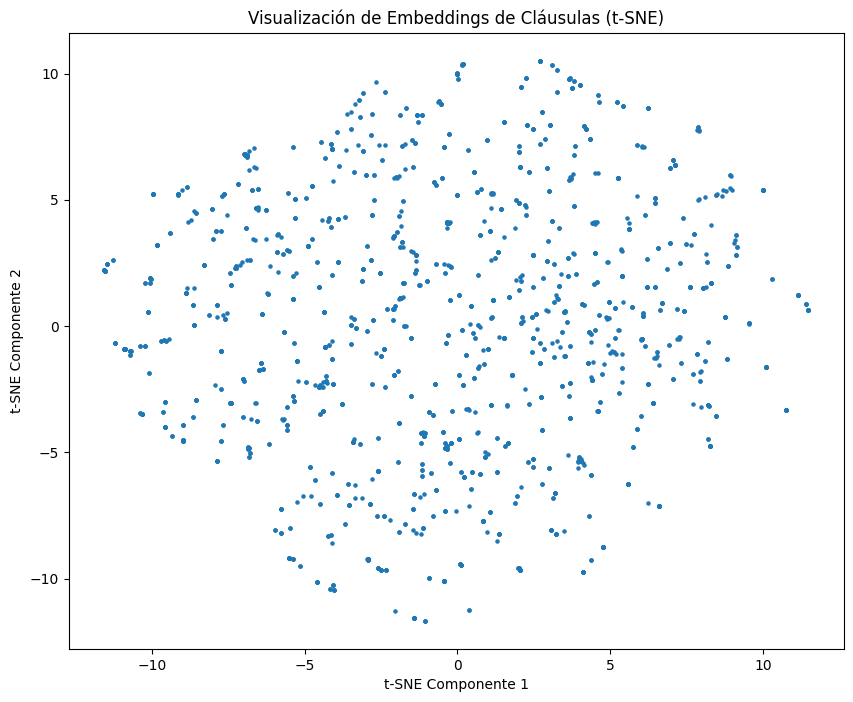

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Se importa las clases PCA y TSNE (hecho arriba)
# 2. Se aplica PCA para reducir los embeddings a 50 componentes
pca = PCA(n_components=50, random_state=42)
embeddings_pca = pca.fit_transform(embeddings)
print(f"Forma de los embeddings después de PCA: {embeddings_pca.shape}")

# 3. Se aplica t-SNE a las 50 componentes PCA para reducir la dimensionalidad a 2 componentes
#    Nos aseguramos de usar un random_state para reproducibilidad.
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
embeddings_tsne = tsne.fit_transform(embeddings_pca)
print(f"Forma de los embeddings después de t-SNE: {embeddings_tsne.shape}")

# 4. Se crea un gráfico de dispersión de los componentes de t-SNE.
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], s=5)

# 5. Se etiqueta los ejes del gráfico
plt.xlabel("t-SNE Componente 1")
plt.ylabel("t-SNE Componente 2")

# 6. Se añade un título al gráfico
plt.title("Visualización de Embeddings de Cláusulas (t-SNE)")

# 7. Se muestra el gráfico.
plt.show()

## Análisis temporal

Se convierte la columna 'periodo_inicio' a formato de fecha y visualizar la distribución de cláusulas a lo largo del tiempo.


/tmp/ipython-input-216424051.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['periodo_inicio'] = pd.to_datetime(df['periodo_inicio'], errors='coerce')


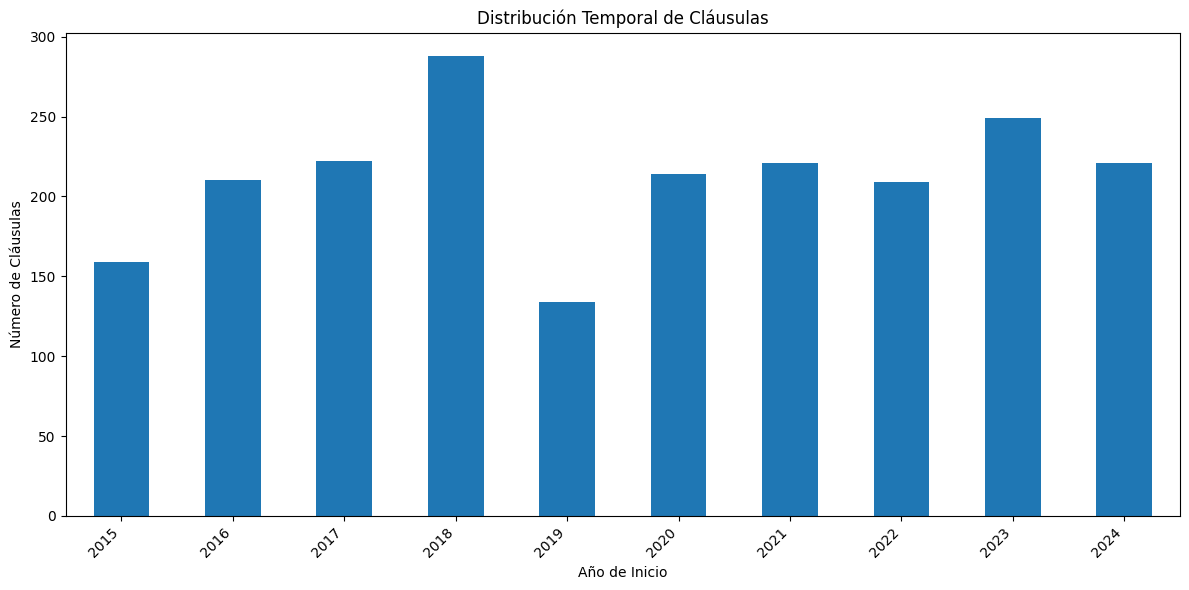

In [ ]:
import matplotlib.pyplot as plt

# 1. Se convierte la columna 'periodo_inicio' a formato de fecha, manejando errores
df['periodo_inicio'] = pd.to_datetime(df['periodo_inicio'], errors='coerce')

# 2. Se eliminan filas con valores nulos (NaT) en 'periodo_inicio'
df.dropna(subset=['periodo_inicio'], inplace=True)

# 3. Se extrae el año de la columna 'periodo_inicio'
df['año_inicio'] = df['periodo_inicio'].dt.year

# 4. Se cuenta la frecuencia de cláusulas por año y ordenar por índice
clause_counts_by_year = df['año_inicio'].value_counts().sort_index()

# 5. Se crea un gráfico de barras
plt.figure(figsize=(12, 6))
clause_counts_by_year.plot(kind='bar')

# 6. Se etiquetan los ejes
plt.xlabel("Año de Inicio")
plt.ylabel("Número de Cláusulas")

# 7. Se añade un título al gráfico
plt.title("Distribución Temporal de Cláusulas")

# Se mejora la legibilidad de las etiquetas del eje X
plt.xticks(rotation=45, ha='right')
plt.tight_layout() # Ajuste para evitar traslape

# 8. Se muestra el gráfico
plt.show()


## Visualizaciones adicionales

Se generan visualizaciones como nube de palabras, matriz de similitud (heatmap) y, si aplica, realizar clustering y visualizar los resultados.


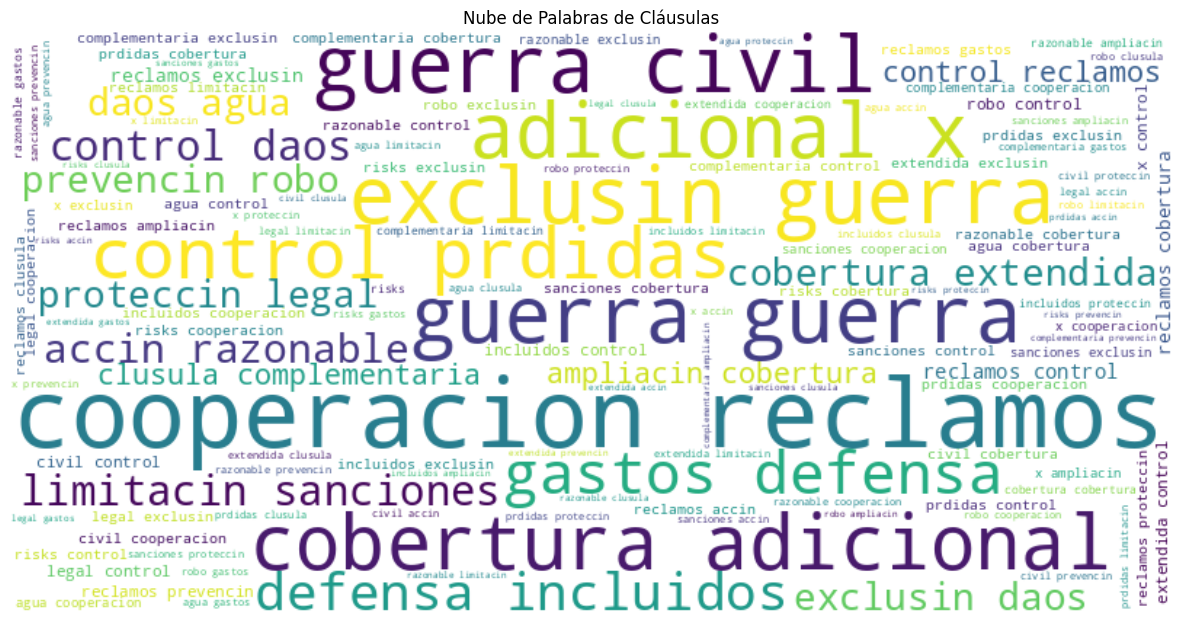

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Se combina todo el texto limpio en una sola cadena
all_text = ' '.join(df['texto_clausulas_limpio'].dropna())

# Se genera la nube de palabras
wordcloud = WordCloud(width=800, height=400, random_state=21, max_font_size=110, background_color='white').generate(all_text)

# Se vizualiza la nube de palabras
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.title('Nube de Palabras de Cláusulas')
plt.show()


# Heatmap
de la matriz de similitud y se realiza clustering en los embeddings, para luego visualizar los clusters en el gráfico t-SNE.



Mostrando heatmap para una muestra de 100 cláusulas.


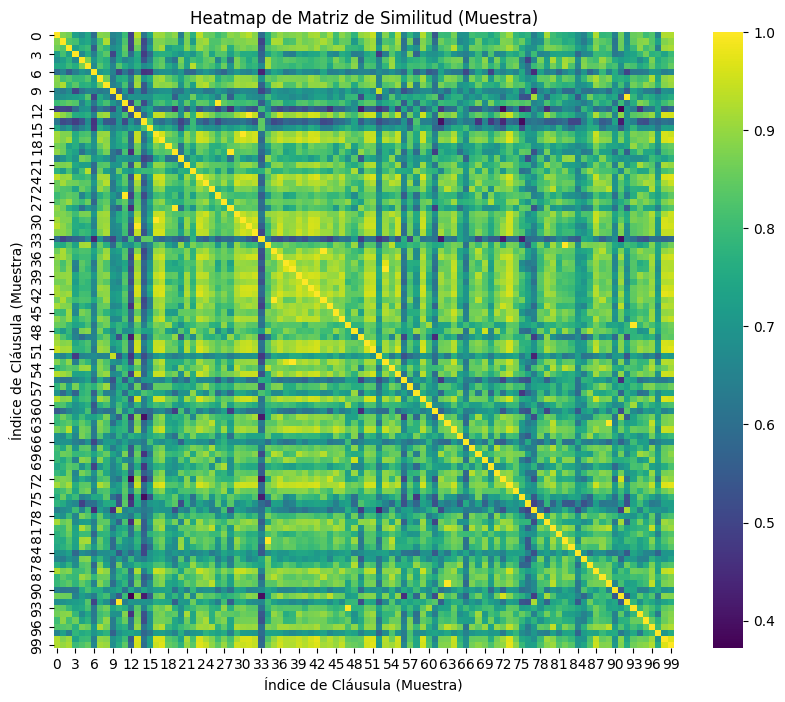


Se han asignado 5 clusters a las cláusulas.


,count
cluster,
0,264
1,935
2,381
3,274
4,273


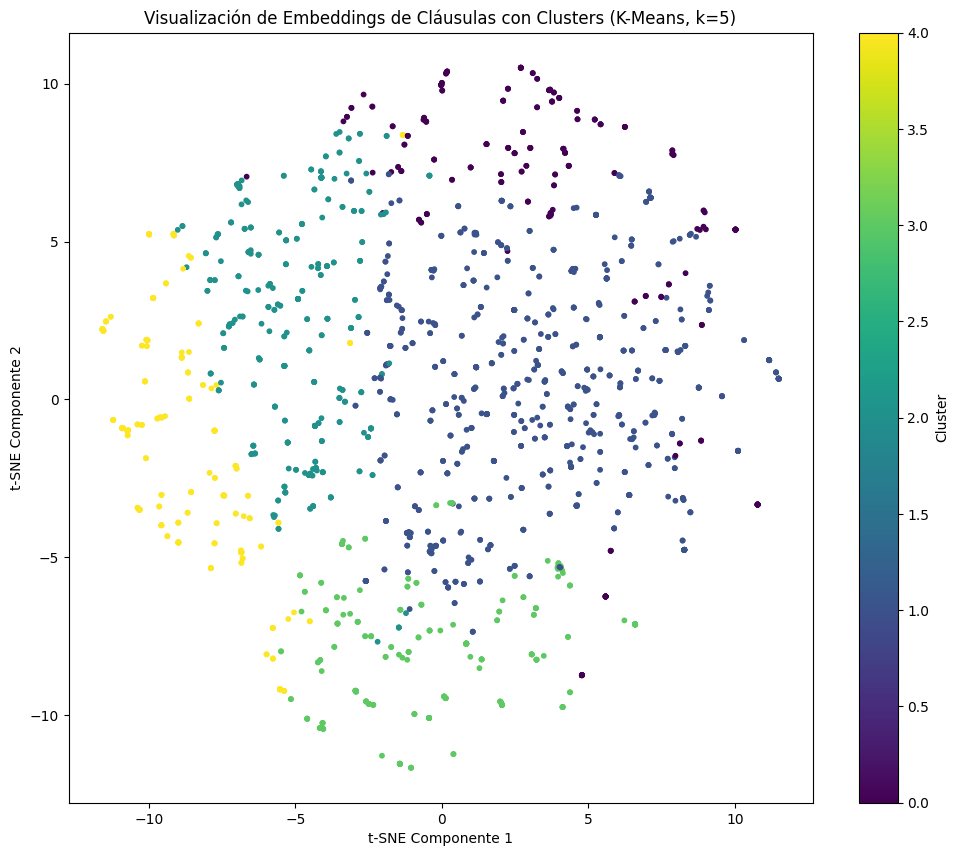

In [ ]:
import seaborn as sns
from sklearn.cluster import KMeans
import numpy as np

# 2. Se crea un heatmap de la matriz de similitud
# Seleccionamos una muestra de la matriz
sample_size = 100 # Definimos 100 como un tamaño de muestra adecuado
if similarity_matrix.shape[0] > sample_size:
    # Se seleccionan índices aleatorios para la muestra
    np.random.seed(42) # para reproducibilidad
    sample_indices = np.random.choice(similarity_matrix.shape[0], sample_size, replace=False)
    similarity_sample = similarity_matrix[np.ix_(sample_indices, sample_indices)]
    print(f"Mostrando heatmap para una muestra de {sample_size} cláusulas.")
else:
    similarity_sample = similarity_matrix
    print("Mostrando heatmap para todas las cláusulas.")


plt.figure(figsize=(10, 8))
sns.heatmap(similarity_sample, cmap='viridis')
plt.title('Heatmap de Matriz de Similitud (Muestra)')
plt.xlabel('Índice de Cláusula (Muestra)')
plt.ylabel('Índice de Cláusula (Muestra)')
plt.show()

# 3. Realizar análisis de clustering (K-Means)
# Elegir un número fijo de clusters inicialmente, por ejemplo 5
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init='auto' en versiones recientes
cluster_labels = kmeans.fit_predict(embeddings_pca) # Usar embeddings_pca para clustering

# Añadir las etiquetas de cluster al DataFrame (opcional pero útil)
df['cluster'] = cluster_labels
print(f"\nSe han asignado {n_clusters} clusters a las cláusulas.")
display(df['cluster'].value_counts().sort_index())


# 4. Se visualizan los clusters en el gráfico de dispersión de t-SNE
plt.figure(figsize=(12, 10))
scatter = plt.scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], c=cluster_labels, cmap='viridis', s=10)

# Se añade una barra de color (leyenda)
plt.colorbar(scatter, label='Cluster')

plt.xlabel("t-SNE Componente 1")
plt.ylabel("t-SNE Componente 2")
plt.title(f"Visualización de Embeddings de Cláusulas con Clusters (K-Means, k={n_clusters})")
plt.show()

##Conclusiones - Fase de Preparación de los Datos (CRISP-ML)

Este análisis exploró un dataset de cláusulas y excepciones para comprender su contenido, similitud semántica, distribución temporal y posibles agrupaciones.

**1. Carga y Preprocesamiento de Datos:**
Se cargó el dataset "reinsurance_data_thb.csv" en un DataFrame de pandas. Las columnas relevantes ('anexos_clausulas', 'texto_clausulas', 'periodo_inicio') fueron verificadas. Se realizó un preprocesamiento de texto en la columna 'texto_clausulas' para crear 'texto_clausulas_limpio'. Este proceso incluyó:
- Conversión a minúsculas.
- Eliminación de caracteres especiales, puntuación y números.
- Tokenización del texto.
- Eliminación de stopwords en español.
Este paso fue crucial para preparar el texto para el análisis de similitud y la generación de embeddings.

**2. Generación y Análisis de Embeddings:**
Se utilizó el modelo pre-entrenado en español 'hiiamsid/sentence_similarity_spanish_es' de la librería `sentence-transformers` para generar embeddings vectoriales de 768 dimensiones para cada cláusula limpia. Estos embeddings capturan la información semántica del texto.
Se calculó la matriz de similitud coseno entre todos los pares de embeddings. Los valores cercanos a 1 indican alta similitud semántica entre cláusulas, mientras que los valores cercanos a 0 indican baja similitud. El heatmap de una muestra de esta matriz visualizó estas relaciones, mostrando bloques de mayor similitud entre ciertas cláusulas.

**3. Visualización de Embeddings y Clustering:**
Para visualizar los embeddings de alta dimensión, se aplicó una reducción de dimensionalidad:
- PCA (Análisis de Componentes Principales) para reducir inicialmente a 50 componentes.
- t-SNE (Distribución de Vecinos Estocásticos Incrustados) aplicado a los componentes de PCA para reducir a 2 dimensiones, adecuadas para visualización en un plano 2D.
El gráfico de dispersión de t-SNE mostró la distribución de las cláusulas en un espacio bidimensional, donde las cláusulas semánticamente similares tienden a agruparse. Se observaron varias concentraciones de puntos, sugiriendo la existencia de diferentes tipos de cláusulas.

Se aplicó el algoritmo de clustering K-Means a los embeddings (usando los resultados de PCA) para agrupar automáticamente las cláusulas en 5 clusters. Al visualizar estos clusters sobre el gráfico de t-SNE, se confirmó que los clusters identificados por K-Means corresponden en gran medida a las agrupaciones visuales observadas en el gráfico de t-SNE sin colorear, indicando que el clustering logró agrupar cláusulas con características semánticas similares.

**4. Análisis Temporal:**
La columna 'periodo_inicio' fue convertida a formato de fecha para analizar la distribución temporal de las cláusulas. Se extrajo el año de inicio de cada cláusula.
El gráfico de barras de la distribución temporal mostró el número de cláusulas por año. Se observó una variación en la cantidad de cláusulas a lo largo del tiempo, con picos y valles en ciertos años. Esto puede reflejar tendencias en la emisión de cláusulas o la disponibilidad de datos.

**5. Nube de Palabras:**
La nube de palabras generada a partir del texto limpio de todas las cláusulas proporcionó una visión rápida de los términos más frecuentes. Palabras como "cooperacion", "reclamos", "exclusiones", "riesgos", "seguro", "notificacion", entre otras, aparecieron prominentemente, reflejando la naturaleza del contenido relacionado con seguros y reaseguros.

**Conclusiones Generales:**
El análisis combinado de embeddings, similitud, visualización y clustering permitió identificar patrones semánticos dentro de las cláusulas. Las agrupaciones en el espacio de embeddings y los clusters sugieren que existen distintos temas o tipos de cláusulas en el dataset. El análisis temporal mostró la evolución en la cantidad de cláusulas a lo largo de los años, mientras que la nube de palabras destacó los términos clave. Estos hallazgos pueden ser útiles para categorizar cláusulas, identificar redundancias o variaciones, y entender la estructura del dataset.
